# 05c — MarsSeg (ResNet-50 + MiniASPP + PSA + SPPM)

**Paper**: Li et al. — *MarsSeg: Mars Surface Semantic Segmentation with Multi-level Extractor and Connector*  
arXiv: `2404.04155` — Beihang University, 2024  

**Arquitectura**: Encoder-decoder basado en ResNet-50 con 3 módulos de mejora de características:  
- **Mini-ASPP**: captura detalles locales multi-escala en features superficiales  
- **PSA** (Polarized Self-Attention): dependencias globales canal + espacio  
- **SPPM** (Strip Pyramid Pooling Module): información semántica de alto nivel  
- **layer4 con dilation=2** para no reducir resolución espacial  

**Advertencia**: Alta varianza en big_rock (±0.054) — el más inestable de los 5 modelos. Supervisar las 3 seeds.

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/ai4mars_DL-v3')
    sys.path.append(str(PROJECT_ROOT / 'notebooks'))
else:
    PROJECT_ROOT = Path('__file__').resolve().parent.parent
    if not (PROJECT_ROOT / 'processed').exists():
        PROJECT_ROOT = Path.cwd().parent

print(f'ROOT: {PROJECT_ROOT} | existe: {PROJECT_ROOT.exists()}')

ROOT: C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3 | existe: True


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights
import numpy as np
import matplotlib.pyplot as plt

from mars_utils import (
    set_seed, load_norm_stats, load_split,
    build_dataloaders, FocalDiceLoss,
    train_one_epoch, evaluate, train_model, run_multi_seed,
    append_benchmark_results, plot_best_seed_curves,
    print_summary_table, visualize_predictions, count_parameters,
    NUM_CLASSES, IGNORE_INDEX, SEEDS
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Configuración

In [3]:
MODEL_NAME   = 'MarsSeg'
FAST_SUBSET  = True   # ← True para prueba rápida (~2 min/seed)

LR           = 0.001
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 80
PATIENCE     = 10
BATCH_SIZE   = 16
FOCAL_ALPHA  = 0.25
FOCAL_GAMMA  = 2.0

print(f'Modo: {"FAST SUBSET" if FAST_SUBSET else "PRODUCCIÓN"}')

Modo: FAST SUBSET


## 2. Datos

In [4]:
df_train, df_val, df_gold = load_split()
mean, std = load_norm_stats()

# ← columna 'stem' no existe en el df; derivarla de image_path
train_ids = set(Path(p).stem for p in df_train['image_path'])
gold_ids  = set(Path(p).stem for p in df_gold['image_path'])
assert len(train_ids & gold_ids) == 0, '⚠️ DATA LEAKAGE detectado'
print(f'✅ Train: {len(df_train)} | Val: {len(df_val)} | Gold: {len(df_gold)}')
print(f'Normalización — mean: {mean} | std: {std}')

✅ Split cargado — train: 4200 | val: 1800 | gold test: 322
✅ Train: 4200 | Val: 1800 | Gold: 322
Normalización — mean: [0.2303263779898021, 0.2303263779898021, 0.2303263779898021] | std: [0.10591342097577364, 0.10591342097577364, 0.10591342097577364]


## 3. Arquitectura — MarsSeg

### 3.1 Módulos de mejora de características

In [5]:
class MiniASPP(nn.Module):
    """
    Mini Atrous Spatial Pyramid Pooling.
    3 ramas de convolución dilatada (rates 1,1,2) para capturar
    representaciones multi-escala locales de forma eficiente.
    Diseñado para feature maps de alta resolución (superficiales).
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        mid = out_channels // 3

        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, mid, 3, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, mid, 3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        # Ajuste de canales tras concatenación
        concat_ch = mid * 3
        self.fuse = nn.Sequential(
            nn.Conv2d(concat_ch, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        return self.fuse(torch.cat([b1, b2, b3], dim=1))


class PolarizedSelfAttention(nn.Module):
    """
    Polarized Self-Attention (PSA).
    Atiende tanto a la dimensión de canal como a la espacial
    mediante auto-atención ligera paralela.
    """
    def __init__(self, channels: int):
        super().__init__()
        self.ch_half = channels // 2

        # Rama canal
        self.ch_q = nn.Conv2d(channels, self.ch_half, 1)
        self.ch_v = nn.Conv2d(channels, self.ch_half, 1)

        # Rama espacial
        self.sp_q = nn.Conv2d(channels, 1, 1)
        self.sp_v = nn.Conv2d(channels, self.ch_half, 1)

        self.norm_ch = nn.LayerNorm([self.ch_half, 1, 1])
        self.fuse    = nn.Conv2d(self.ch_half, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape

        # Atención de canal
        q_ch = self.ch_q(x).reshape(B, self.ch_half, -1)        # (B, C/2, HW)
        v_ch = self.ch_v(x).reshape(B, self.ch_half, -1)        # (B, C/2, HW)
        attn_ch = F.softmax(q_ch, dim=-1)                        # (B, C/2, HW)
        ch_out = (v_ch * attn_ch).sum(dim=-1, keepdim=True)      # (B, C/2, 1)
        ch_out = ch_out.unsqueeze(-1)                            # (B, C/2, 1, 1)
        ch_out = torch.sigmoid(self.norm_ch(ch_out))             # (B, C/2, 1, 1)

        # Atención espacial
        q_sp = self.sp_q(x).reshape(B, 1, -1)                   # (B, 1, HW)
        v_sp = self.sp_v(x).reshape(B, self.ch_half, -1)        # (B, C/2, HW)
        attn_sp = F.softmax(q_sp, dim=-1)                        # (B, 1, HW)
        sp_out = (v_sp * attn_sp).sum(dim=-1)                    # (B, C/2)
        sp_out = torch.sigmoid(sp_out).reshape(B, self.ch_half, 1, 1)  # (B, C/2, 1, 1)

        # Combinar y proyectar
        combined = ch_out * sp_out                               # (B, C/2, 1, 1)
        return x + self.fuse(combined)


class SPPM(nn.Module):
    """
    Strip Pyramid Pooling Module.
    Combina pooling global multi-escala (1×1, 2×2, 4×4, 8×8) con
    pooling en franja (1×W y H×1) para capturar información semántica
    de categorías a múltiples escalas, incluido terreno en franja.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # Reducción de canales antes del pooling
        self.reduce = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
        # Ramas de pooling multi-escala
        self.pools = nn.ModuleList([
            nn.AdaptiveAvgPool2d(s) for s in [1, 2, 4, 8]
        ])
        n_branches = len(self.pools) + 2  # +2 por strip H y W
        self.fuse = nn.Sequential(
            nn.Conv2d(out_channels * (1 + n_branches), out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x_r = self.reduce(x)
        H, W = x_r.shape[-2:]
        parts = [x_r]
        for pool in self.pools:
            parts.append(
                F.interpolate(pool(x_r), size=(H, W), mode='bilinear', align_corners=False)
            )
        # Strip pooling H y W
        strip_h = F.adaptive_avg_pool2d(x_r, (1, W))
        strip_w = F.adaptive_avg_pool2d(x_r, (H, 1))
        parts.append(F.interpolate(strip_h, (H, W), mode='bilinear', align_corners=False))
        parts.append(F.interpolate(strip_w, (H, W), mode='bilinear', align_corners=False))
        return self.fuse(torch.cat(parts, dim=1))

In [6]:
class MarsSeg(nn.Module):
    """
    MarsSeg: encoder-decoder con ResNet-50 y capas de mejora de características.
    
    Flujo:
      Input [B,3,256,256]
        ↓ ResNet-50 layer1 (C=256, H/4×W/4)   → MiniASPP + PSA → feat1
        ↓ ResNet-50 layer2 (C=512, H/8×W/8)   → MiniASPP + PSA → feat2
        ↓ ResNet-50 layer3 (C=1024, H/16×W/16) → MiniASPP + PSA → feat3
        ↓ ResNet-50 layer4 (C=2048, dilation=2, H/16×W/16) → SPPM → feat4
        ↓ Decoder: upsample + concat + conv × 2 → logits [B,4,256,256]
    
    Solo se usan los 3 primeros feature maps (shallow) con dilation en layer4.
    """
    def __init__(self, num_classes: int = 4):
        super().__init__()

        # --- Encoder: ResNet-50 con dilation en layer4 ---
        backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1,
                                    backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1   # out: 256ch, H/4
        self.layer2 = backbone.layer2   # out: 512ch, H/8
        self.layer3 = backbone.layer3   # out: 1024ch, H/16
        # layer4 con dilation=2 para mantener resolución H/16
        self.layer4 = backbone.layer4
        self._set_dilation(self.layer4, dilation=2)

        # --- Feature Enhancement ---
        self.mini_aspp1 = MiniASPP(256, 128)
        self.psa1       = PolarizedSelfAttention(128)

        self.mini_aspp2 = MiniASPP(512, 256)
        self.psa2       = PolarizedSelfAttention(256)

        self.mini_aspp3 = MiniASPP(1024, 512)
        self.psa3       = PolarizedSelfAttention(512)

        self.sppm = SPPM(2048, 512)

        # --- Decoder ---
        # Capa 4 (H/16, 512) + Capa 3 (H/16, 512) → fusión
        self.fuse43 = self._conv_block(512 + 512, 256)
        # Upsample a H/8 + Capa 2 (H/8, 256)
        self.fuse2  = self._conv_block(256 + 256, 128)
        # Upsample a H/4 + Capa 1 (H/4, 128)
        self.fuse1  = self._conv_block(128 + 128, 64)
        # Upsample a H×W → clasificador final
        self.head   = nn.Conv2d(64, num_classes, 1)

    @staticmethod
    def _set_dilation(layer, dilation: int):
        """Aplica dilation a todas las conv 3×3 de un bloque residual."""
        for m in layer.modules():
            if isinstance(m, nn.Conv2d) and m.kernel_size == (3, 3):
                m.dilation  = (dilation, dilation)
                m.padding   = (dilation, dilation)
                m.stride    = (1, 1)
            elif isinstance(m, nn.Conv2d) and m.stride == (2, 2):
                m.stride = (1, 1)

    @staticmethod
    def _conv_block(in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        H, W = x.shape[-2:]

        # Encoder
        x0 = self.layer0(x)          # H/4
        x1 = self.layer1(x0)         # H/4,  256ch
        x2 = self.layer2(x1)         # H/8,  512ch
        x3 = self.layer3(x2)         # H/16, 1024ch
        x4 = self.layer4(x3)         # H/16, 2048ch (dilation=2)

        # Feature enhancement
        f1 = self.psa1(self.mini_aspp1(x1))   # H/4,  128ch
        f2 = self.psa2(self.mini_aspp2(x2))   # H/8,  256ch
        f3 = self.psa3(self.mini_aspp3(x3))   # H/16, 512ch
        f4 = self.sppm(x4)                     # H/16, 512ch

        # Decoder
        d43 = self.fuse43(torch.cat([f4, f3], dim=1))             # H/16, 256ch
        d43_up = F.interpolate(d43, size=f2.shape[-2:],
                               mode='bilinear', align_corners=False)
        d2  = self.fuse2(torch.cat([d43_up, f2], dim=1))          # H/8, 128ch
        d2_up  = F.interpolate(d2, size=f1.shape[-2:],
                               mode='bilinear', align_corners=False)
        d1  = self.fuse1(torch.cat([d2_up, f1], dim=1))           # H/4, 64ch
        out = F.interpolate(self.head(d1), size=(H, W),
                            mode='bilinear', align_corners=False)  # H×W, 4ch
        return out


def build_model():
    return MarsSeg(num_classes=NUM_CLASSES).to(DEVICE)


# Verificación
_m = build_model()
_m.eval()
with torch.no_grad():
    _x = torch.randn(2, 3, 256, 256).to(DEVICE)
    _out = _m(_x)
    print(f'Forward OK — salida: {_out.shape}')  # (2, 4, 256, 256)

n_params = count_parameters(_m)
print(f'Parámetros entrenables: {n_params:.2f}M  (referencia KB: ~38.61M)')
del _m, _x, _out

Forward OK — salida: torch.Size([2, 4, 256, 256])
Parámetros entrenables: 34.87M  (referencia KB: ~38.61M)


## 4. Loss, Optimizer y Scheduler

In [7]:
def criterion_fn():
    # FocalDiceLoss — combina Focal + Dice para class imbalance
    return FocalDiceLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA,
                         ignore_index=IGNORE_INDEX)


def optimizer_fn(params):
    return torch.optim.SGD(
        params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
    )


def scheduler_fn(optimizer):
    return torch.optim.lr_scheduler.PolynomialLR(
        optimizer, total_iters=MAX_EPOCHS, power=0.9
    )


print('✅ Loss: FocalDiceLoss (α=0.25, γ=2.0)')
print('  Optimizer: SGD (lr=0.001, momentum=0.9, wd=1e-4)')
print('  Scheduler: PolynomialLR (power=0.9)')

✅ Loss: FocalDiceLoss (α=0.25, γ=2.0)
  Optimizer: SGD (lr=0.001, momentum=0.9, wd=1e-4)
  Scheduler: PolynomialLR (power=0.9)


## 5. Entrenamiento Multi-Seed

In [10]:
summary = run_multi_seed(
    model_fn       = build_model,
    df_train       = df_train,
    df_val         = df_val,
    df_gold        = df_gold,
    criterion_fn   = criterion_fn,
    optimizer_fn   = optimizer_fn,
    scheduler_fn   = scheduler_fn,
    model_name     = MODEL_NAME,
    device         = DEVICE,
    num_epochs     = MAX_EPOCHS,
    patience       = PATIENCE,
    batch_size     = BATCH_SIZE,
    fast_subset    = FAST_SUBSET,
    n_train_fast   = 200,
    n_val_fast     = 50,
)


───────────────────────────────────────────────────────
  Seed 42 | MarsSeg
⚡ Subset rápido — train: 200 | val: 50
   (Para entrenamiento real usar df_train y df_val completos)
  Entrenamiento desde cero

  MarsSeg_seed42 | device=cuda | AMP=True
  epochs=80 | patience=10 | aux_weight=0.0
Ep   1/80 | loss=0.9868 mIoU=0.1124 | val_loss=0.9478 val_mIoU=0.1026 | rock=0.0107
Ep   2/80 | loss=0.8779 mIoU=0.2208 | val_loss=0.9001 val_mIoU=0.1773 | rock=0.0139
Ep   3/80 | loss=0.7840 mIoU=0.3453 | val_loss=0.7793 val_mIoU=0.3373 | rock=0.0247
Ep   4/80 | loss=0.7077 mIoU=0.4090 | val_loss=0.7050 val_mIoU=0.3884 | rock=0.0304
Ep   5/80 | loss=0.6613 mIoU=0.4500 | val_loss=0.5882 val_mIoU=0.4930 | rock=0.0057
Checkpoint periódico guardado (epoch 5)
Ep   6/80 | loss=0.6214 mIoU=0.4597 | val_loss=0.4976 val_mIoU=0.5673 | rock=0.0035
Ep   7/80 | loss=0.6296 mIoU=0.4930 | val_loss=0.5247 val_mIoU=0.5424 | rock=0.0137
Ep   8/80 | loss=0.5758 mIoU=0.5172 | val_loss=0.5239 val_mIoU=0.5365 | rock=0.00

## 6. Resultados Agregados

In [11]:
print_summary_table(summary)


  RESUMEN — MarsSeg
  Métrica                 Media       Std      IC95
  ------------------------------------------------
  mIoU                   0.7054    0.0318  ± 0.0360
  Pixel Accuracy         0.9416
  ------------------------------------------------
  IoU soil               0.9145    0.0192
  IoU bedrock            0.8714    0.0214
  IoU sand               0.8627    0.0180
  IoU big_rock           0.1731    0.1233
  ------------------------------------------------
  Params (M)           —
  Tiempo medio (s)          241
  Epoch mejor (mean)       38.0



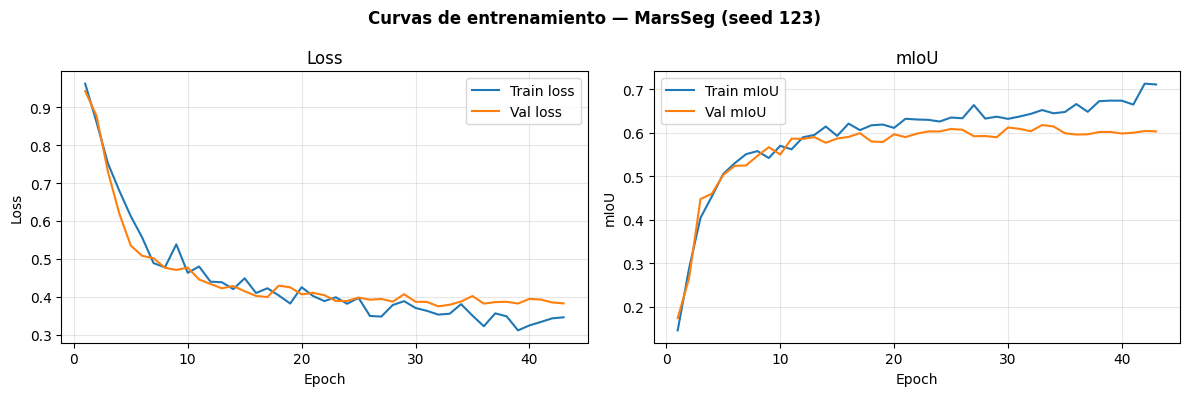

In [12]:
plot_best_seed_curves(summary)

In [17]:
import pandas as pd

# Eliminar filas anteriores del mismo modelo si existen
from mars_utils import BENCHMARK_CSV
if BENCHMARK_CSV.exists():
    df_csv = pd.read_csv(BENCHMARK_CSV)
    df_csv = df_csv[df_csv["model"] != MODEL_NAME]
    df_csv.to_csv(BENCHMARK_CSV, index=False)

append_benchmark_results(summary, params_M=params_M)

Resultados guardados en C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\results\benchmark_results.csv


## 7. Visualización Cualitativa

Mejor seed: 123 | mIoU gold: 0.7446


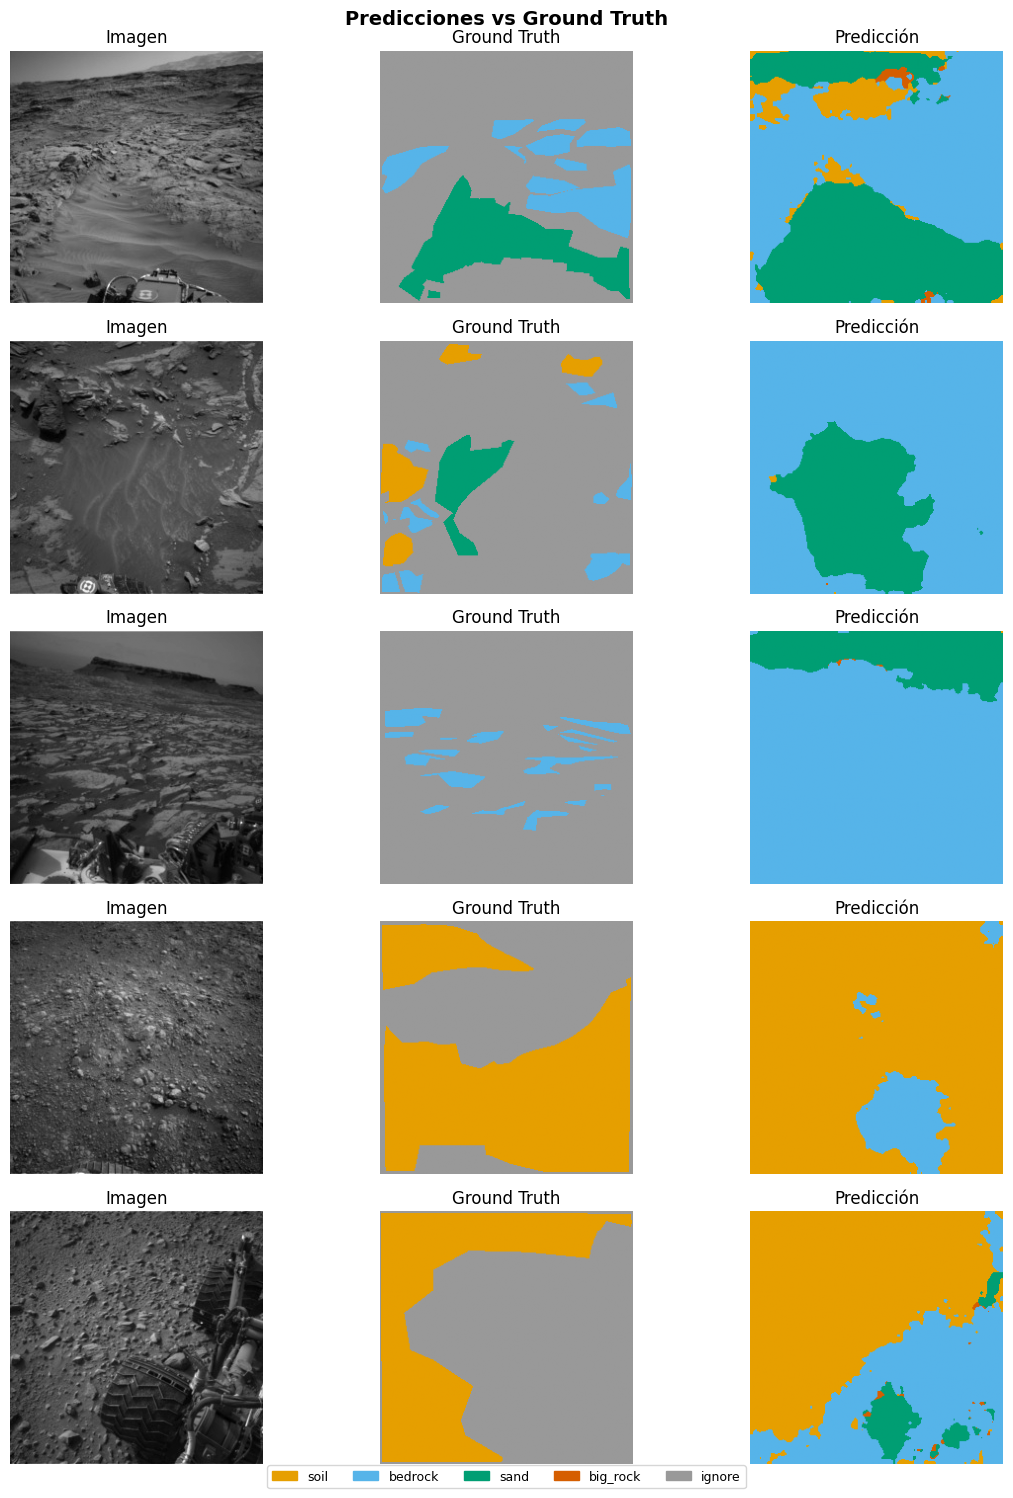

In [15]:
from mars_utils import CHECKPOINTS_DIR

best_seed = max(summary["per_seed"], key=lambda r: r["mIoU"])["seed"]
print(f"Mejor seed: {best_seed} | mIoU gold: {max(summary['per_seed'], key=lambda r: r['mIoU'])['mIoU']:.4f}")

best_model = build_model().to(DEVICE)
ckpt = torch.load(
    CHECKPOINTS_DIR / f"{MODEL_NAME}_seed{best_seed}_best.pth",
    map_location=DEVICE,
)
best_model.load_state_dict(ckpt["model_state"])
best_model.eval()

visualize_predictions(best_model, df_gold, DEVICE, mean=mean, std=std, n=5)

## 8. Resumen Final

| Campo | Valor |
|-------|-------|
| Modelo | MarsSeg |
| Paper | Li et al., arXiv 2404.04155 (2024) |
| Backbone | ResNet-50 + MiniASPP + PSA + SPPM |
| Loss | FocalDiceLoss (α=0.25, γ=2.0) |
| Optimizer | SGD (lr=0.001, momentum=0.9) |
| Scheduler | PolynomialLR (power=0.9) |
| layer4 | dilation=2 (mantiene resolución H/16) |
| Advertencia | Alta varianza en big_rock (±0.054) |
| Referencia histórica (2.1k imgs) | mIoU = 0.6601 ± 0.0122 |

---
*Resultados del gold set exportados a `results/benchmark_results.csv`.*

In [18]:
import inspect
from mars_utils import train_model
print(inspect.signature(train_model))

(model, train_loader, val_loader, optimizer, scheduler, criterion, device, model_name: str = 'model', num_epochs: int = 80, patience: int = 10, aux_weight: float = 0.0, use_amp: bool = True) -> tuple
